In [2]:
!pip install pandas matplotlib seaborn numpy

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

#Load data
df = pd.read_csv("/content/ETTh1.csv", parse_dates=['date'])
df = df.set_index('date')

In [7]:
df.info()
df.head(100)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17420 entries, 2016-07-01 00:00:00 to 2018-06-26 19:00:00
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HUFL    17420 non-null  float64
 1   HULL    17420 non-null  float64
 2   MUFL    17420 non-null  float64
 3   MULL    17420 non-null  float64
 4   LUFL    17420 non-null  float64
 5   LULL    17420 non-null  float64
 6   OT      17420 non-null  float64
dtypes: float64(7)
memory usage: 1.1 MB


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000
...,...,...,...,...,...,...,...
2016-07-04 23:00:00,12.726,6.497,9.346,3.482,3.168,1.980,25.466000
2016-07-05 00:00:00,11.989,5.626,8.777,2.949,3.198,1.980,25.958000
2016-07-05 01:00:00,12.525,6.296,8.955,3.163,3.137,2.010,25.958000


In [5]:
# 1) Shape and basic info of the data
print(f"Shape of the dataset:{df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Frequency: {pd.infer_freq(df.index)}")
print(f"\nMissing values: \n{df.isnull().sum()}")
print(f"\nBasic stats: \n{df.describe()}")

Shape of the dataset:(17420, 7)
Date range: 2016-07-01 00:00:00 to 2018-06-26 19:00:00
Frequency: h

Missing values: 
HUFL    0
HULL    0
MUFL    0
MULL    0
LUFL    0
LULL    0
OT      0
dtype: int64

Basic stats: 
               HUFL          HULL          MUFL          MULL          LUFL  \
count  17420.000000  17420.000000  17420.000000  17420.000000  17420.000000   
mean       7.375141      2.242242      4.300239      0.881568      3.066062   
std        7.067744      2.042342      6.826978      1.809293      1.164506   
min      -22.705999     -4.756000    -25.087999     -5.934000     -1.188000   
25%        5.827000      0.737000      3.296000     -0.284000      2.315000   
50%        8.774000      2.210000      5.970000      0.959000      2.833000   
75%       11.788000      3.684000      8.635000      2.203000      3.625000   
max       23.643999     10.114000     17.341000      7.747000      8.498000   

               LULL            OT  
count  17420.000000  17420.000000  


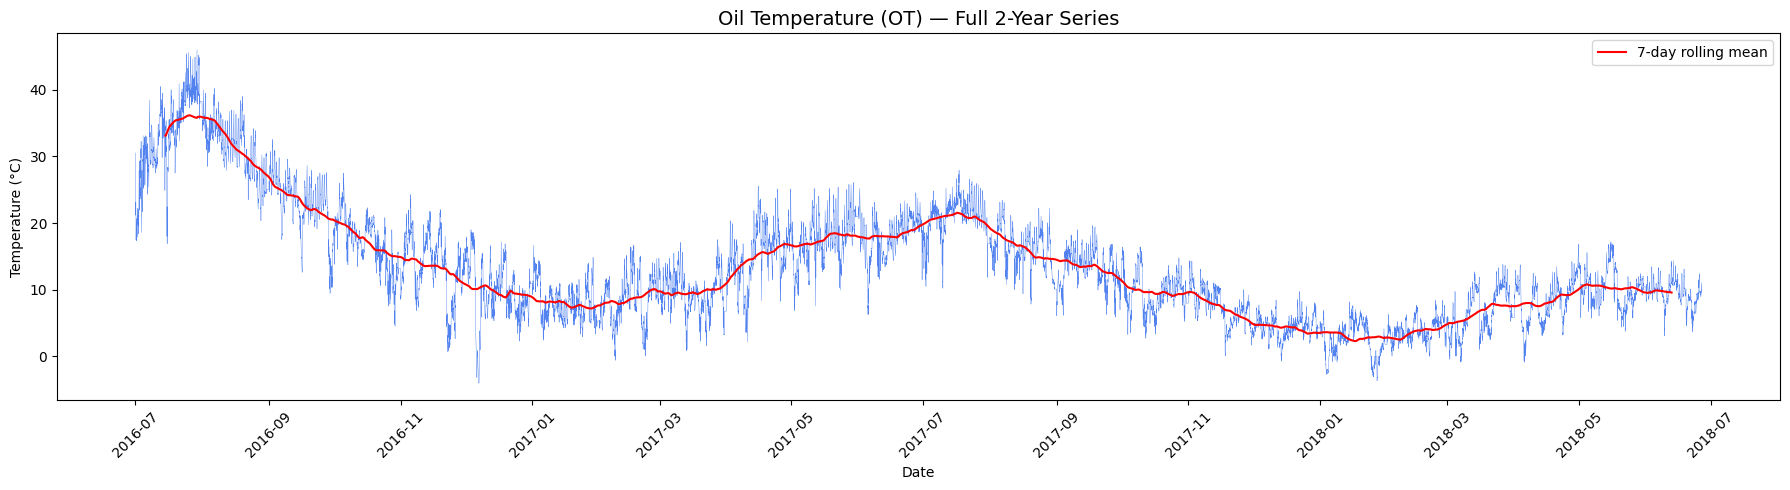


--- Quick anomaly check ---
OT mean: 13.32, std: 8.57
Points beyond 3 std: 159 / 17420 (0.91%)


In [10]:
#2) Whole dataset visualization

# --- Plot full 2-year OT series ---
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df.index, df['OT'], linewidth=0.3, color='#2563eb', alpha=0.8)

# Add a 7-day rolling mean to see the trend more clearly
# Why 7-day? It smooths out daily cycles, revealing longer-term movement
rolling_mean = df['OT'].rolling(window=96*7, center=True).mean()
ax.plot(df.index, rolling_mean, color='red', linewidth=1.5, label='7-day rolling mean')

ax.set_title('Oil Temperature (OT) — Full 2-Year Series', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Visual inspection notes ---
# Print some quick checks for anomalies
print("\n--- Quick anomaly check ---")
mean, std = df['OT'].mean(), df['OT'].std()
outliers = df[np.abs(df['OT'] - mean) > 3 * std]
print(f"OT mean: {mean:.2f}, std: {std:.2f}")
print(f"Points beyond 3 std: {len(outliers)} / {len(df)} ({100*len(outliers)/len(df):.2f}%)")

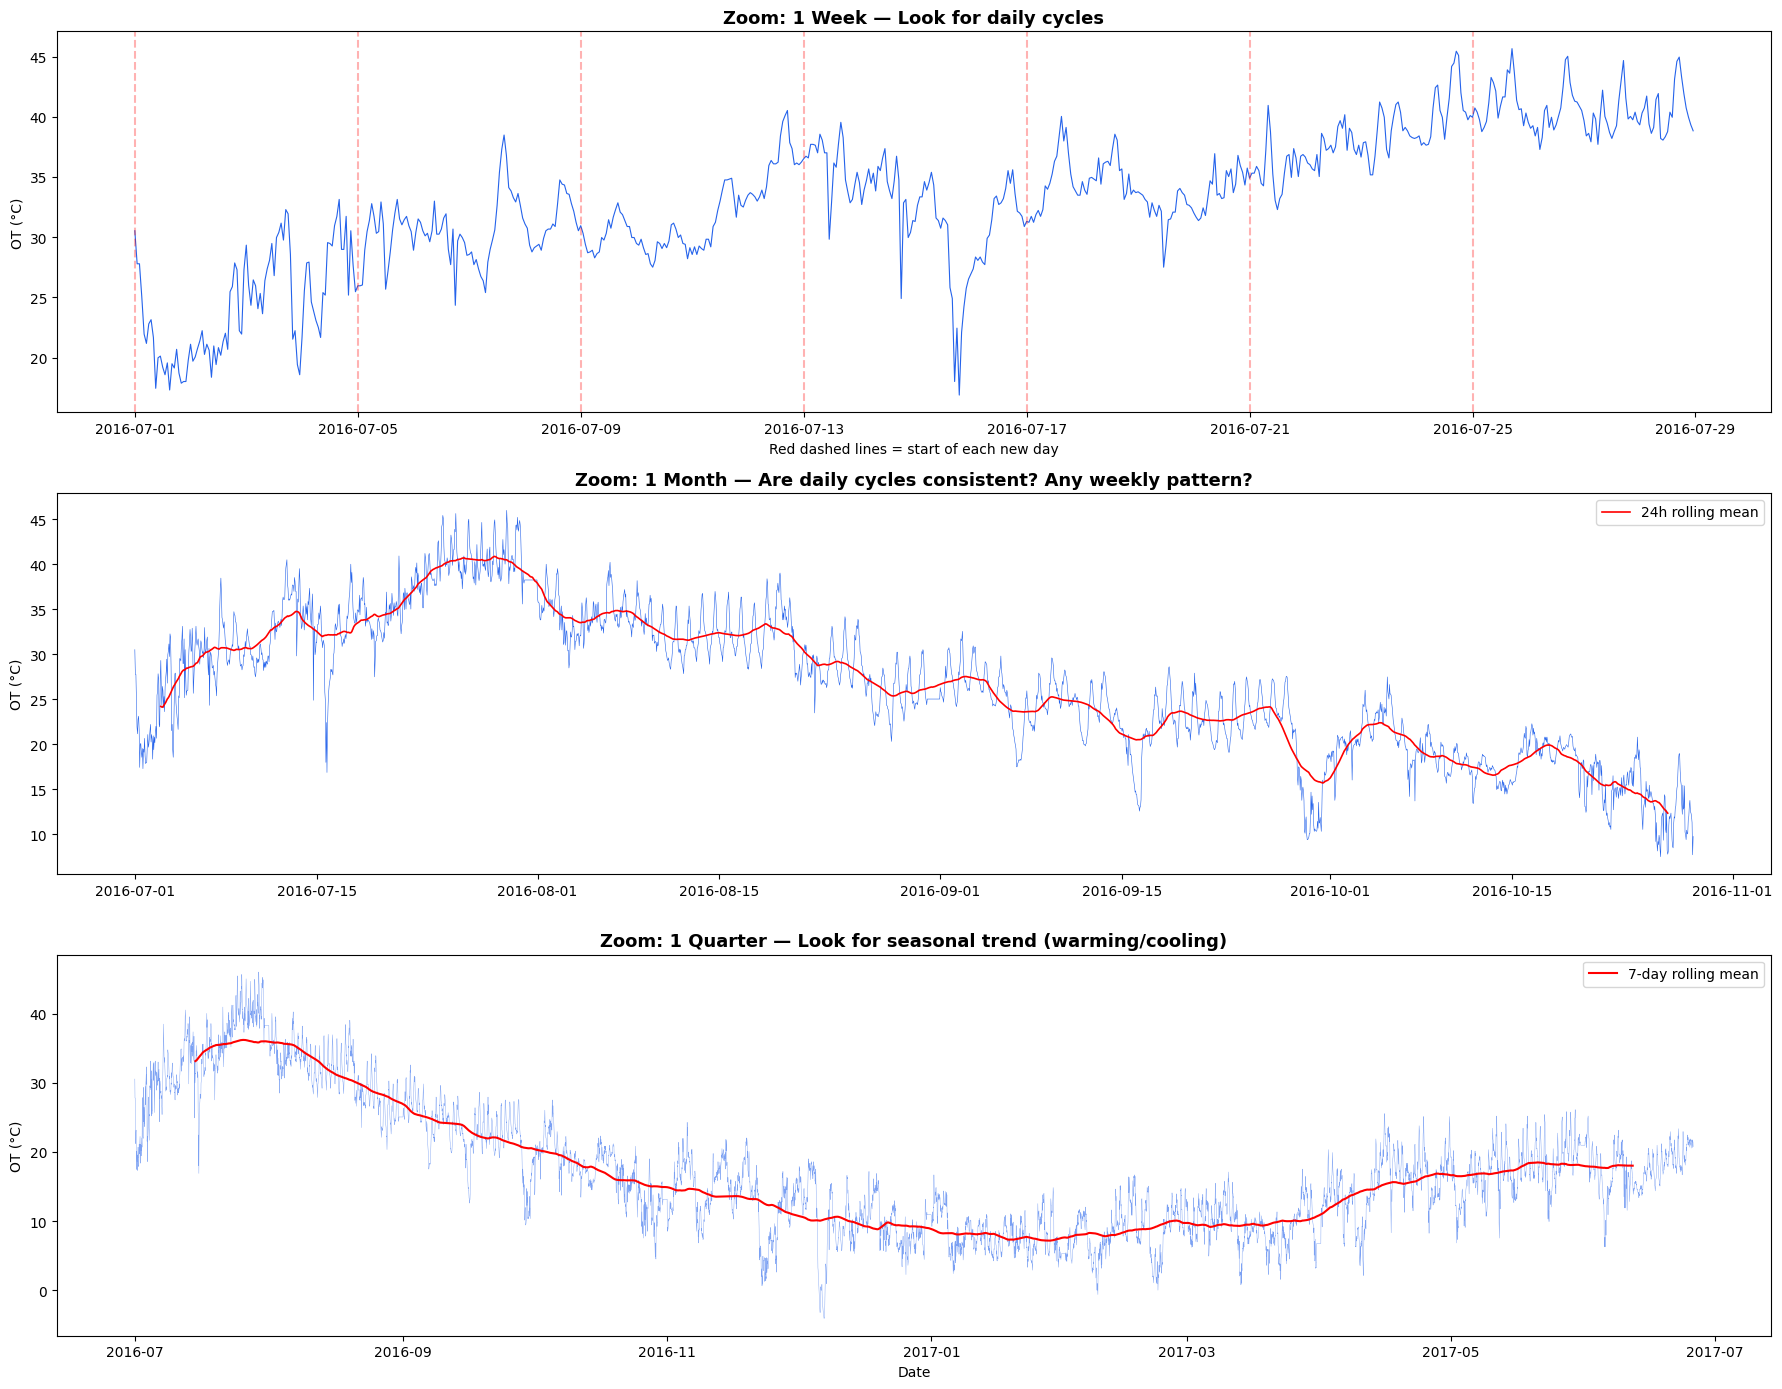

=== What to look for at each zoom level ===
WEEK:    Do you see a repeating up-down pattern every day?
MONTH:   Is the daily pattern stable, or does it drift?
QUARTER: Is there an overall warming or cooling trend?


In [14]:
#3) Data zooming for comparison in each week, month, quater
# ============================================================
# STEP 2: MULTI-SCALE ZOOM
# Purpose: Different patterns emerge at different time scales.
#   - 1 week  → daily cycles become very clear
#   - 1 month → can see if daily pattern is consistent
#   - 1 quarter → seasonal trend (summer vs winter) appears
# Rule of thumb: always look at your data at 3+ zoom levels.
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# --- Zoom 1: One week (first week of data) ---
# At this scale, you should see the 24-hour daily cycle clearly
# Each day: temperature rises during daytime, drops at night
one_week = df.iloc[:96*7]  # 96 points/day * 7 days
axes[0].plot(one_week.index, one_week['OT'], linewidth=0.8, color='#2563eb')
# Mark each new day with a vertical line
for i in range(8):
    if i * 96 < len(one_week):
        axes[0].axvline(one_week.index[i*96], color='red', alpha=0.3, linestyle='--')
axes[0].set_title('Zoom: 1 Week — Look for daily cycles', fontsize=13, fontweight='bold')
axes[0].set_ylabel('OT (°C)')
axes[0].set_xlabel('Red dashed lines = start of each new day')

# --- Zoom 2: One month ---
# At this scale, you can see:
#   - Whether daily cycles are consistent day after day
#   - Any weekly patterns (weekday vs weekend)
#   - Short-term trend within the month
one_month = df.iloc[:96*30]
axes[1].plot(one_month.index, one_month['OT'], linewidth=0.4, color='#2563eb')
# Add daily rolling mean to see weekly pattern
daily_mean = one_month['OT'].rolling(window=96, center=True).mean()
axes[1].plot(one_month.index, daily_mean, color='red', linewidth=1.2, label='24h rolling mean')
axes[1].set_title('Zoom: 1 Month — Are daily cycles consistent? Any weekly pattern?', fontsize=13, fontweight='bold')
axes[1].set_ylabel('OT (°C)')
axes[1].legend()

# --- Zoom 3: One quarter (3 months) ---
# At this scale, seasonal trend becomes visible
# Summer months should be warmer than winter months
one_quarter = df.iloc[:96*90]
axes[2].plot(one_quarter.index, one_quarter['OT'], linewidth=0.3, color='#2563eb', alpha=0.6)
# Use weekly rolling mean to smooth out daily noise
weekly_mean = one_quarter['OT'].rolling(window=96*7, center=True).mean()
axes[2].plot(one_quarter.index, weekly_mean, color='red', linewidth=1.5, label='7-day rolling mean')
axes[2].set_title('Zoom: 1 Quarter — Look for seasonal trend (warming/cooling)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('OT (°C)')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()

# --- Key observations to note ---
print("=== What to look for at each zoom level ===")
print("WEEK:    Do you see a repeating up-down pattern every day?")
print("MONTH:   Is the daily pattern stable, or does it drift?")
print("QUARTER: Is there an overall warming or cooling trend?")

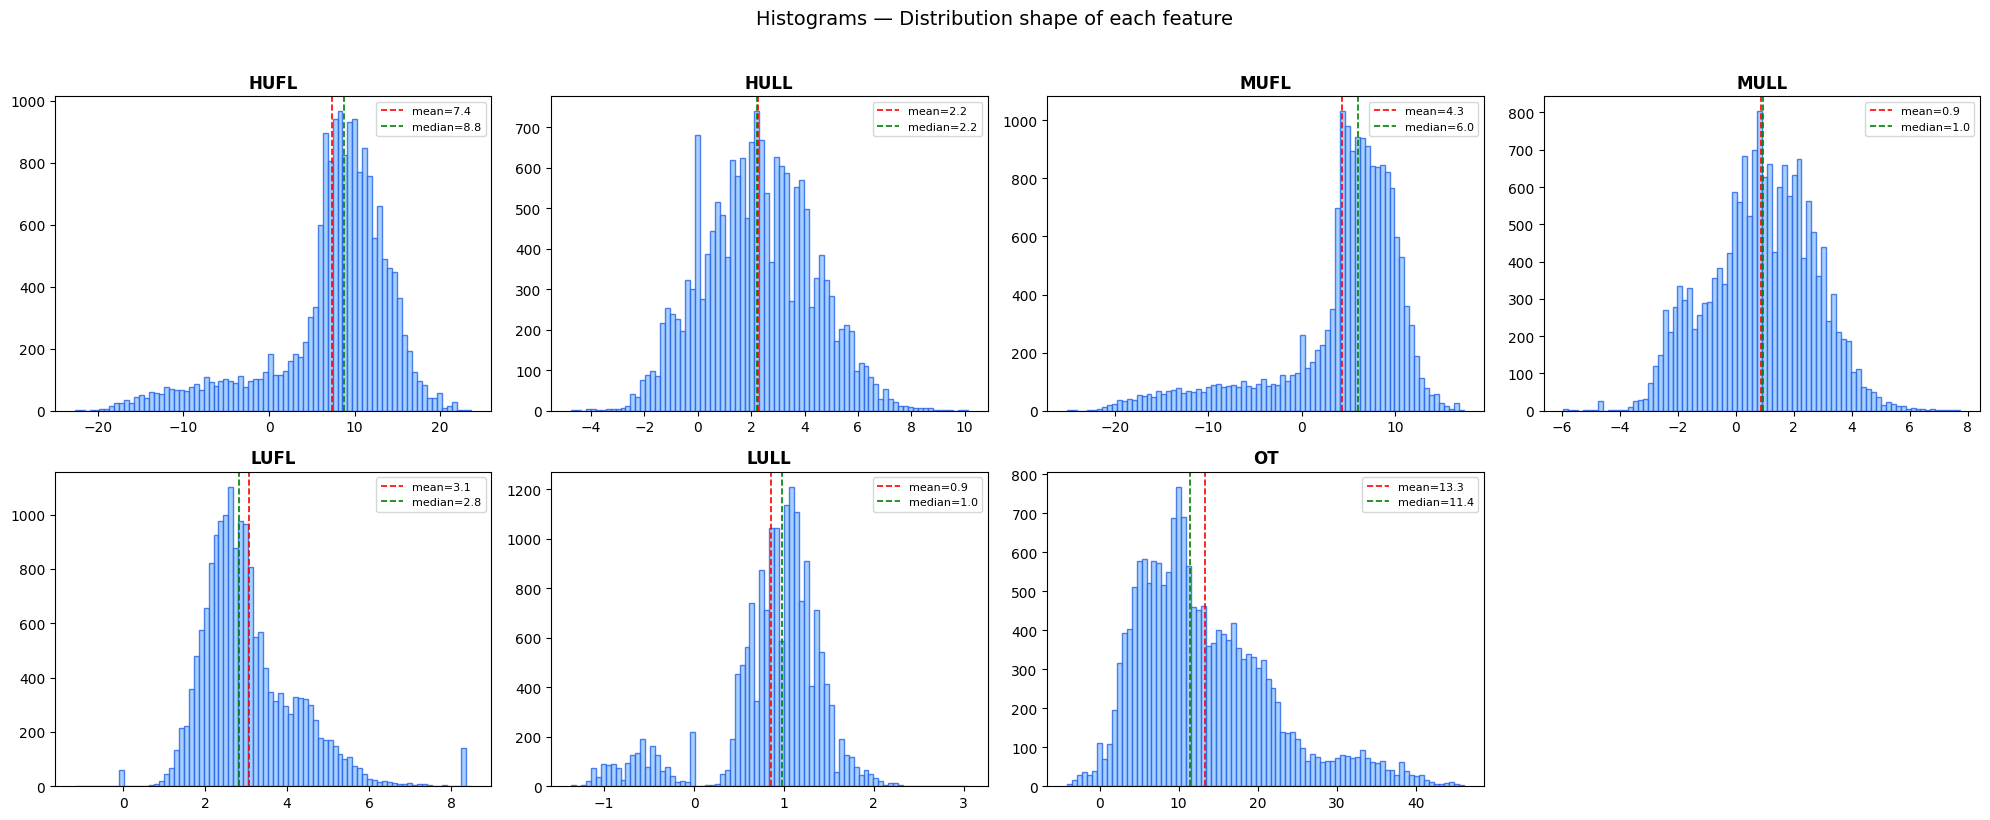

/tmp/ipykernel_2466/2190887000.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([df[col].values for col in features], labels=features, patch_artist=True,
/tmp/ipykernel_2466/2190887000.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_standardized[col].values for col in features], labels=features, patch_artist=True,


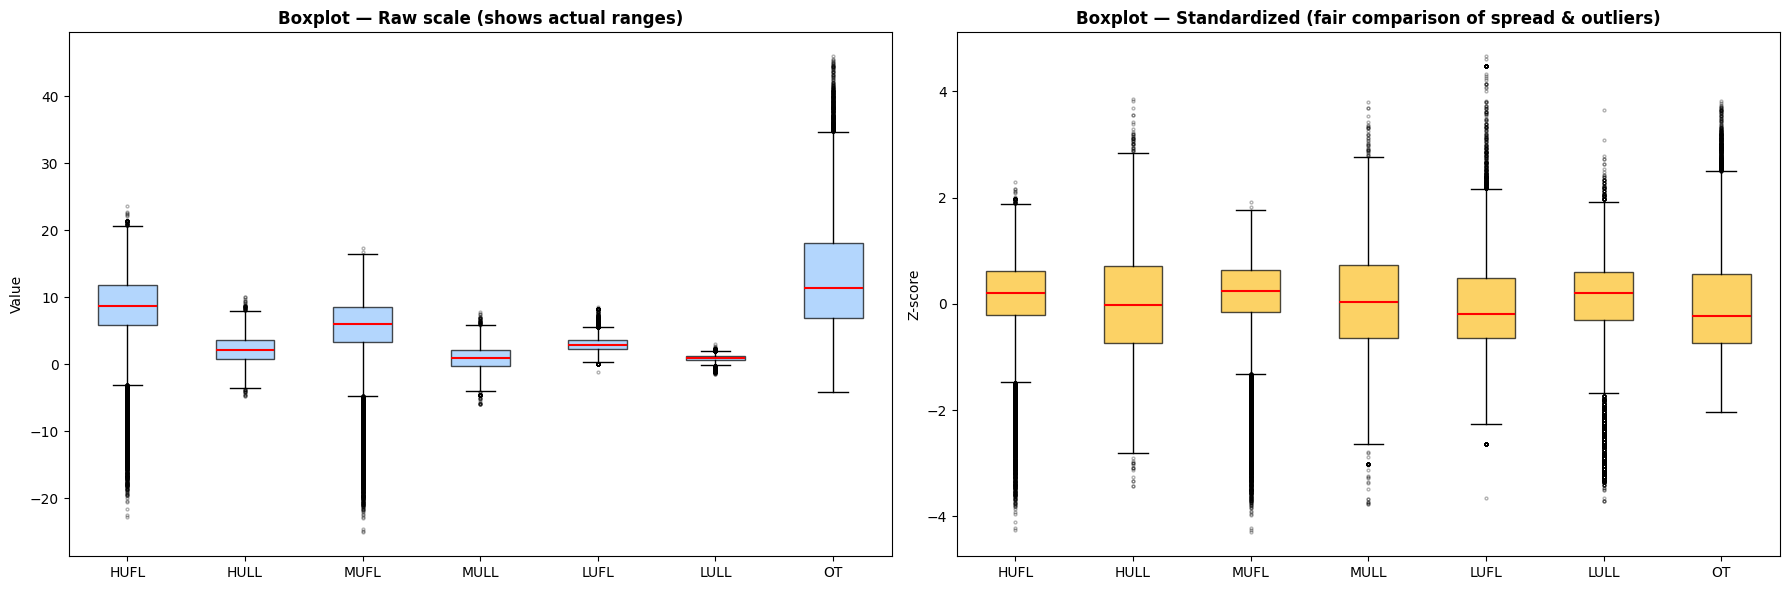

=== Distribution Summary ===
Feature      Mean      Std     Skew Kurtosis Outliers(3σ)
--------------------------------------------------------
HUFL         7.38     7.07    -1.38     1.95          297
HULL         2.24     2.04     0.10    -0.31           41
MUFL         4.30     6.83    -1.61     2.35          366
MULL         0.88     1.81    -0.14    -0.24           61
LUFL         3.07     1.16     1.27     2.96          219
LULL         0.86     0.60    -1.36     2.08          323
OT          13.32     8.57     0.97     0.78          159


In [15]:
#4) Distribution of each attribute for checking missing value
# ============================================================
# STEP 3: DISTRIBUTION ANALYSIS
# Purpose: Understand the statistical shape of each feature.
#   - Is it normal? Skewed? Bimodal?
#   - Are there outliers?
#   - How do features compare in scale and spread?
# Why this matters for modeling:
#   - Skewed distributions may need transformation (log, sqrt)
#   - Outliers can hurt model training (especially MSE-based loss)
#   - Very different scales → need normalization/standardization
# ============================================================

features = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

# --- Part 1: Histogram for each feature ---
# Histograms show the overall shape of the distribution
# Look for: skewness, multiple peaks (bimodal), long tails
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    ax.hist(df[col], bins=80, color='#93c5fd', edgecolor='#2563eb', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label=f'mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=1.2, label=f'median={df[col].median():.1f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

# Hide the last empty subplot
axes[-1].set_visible(False)
fig.suptitle('Histograms — Distribution shape of each feature', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Part 2: Boxplot for all features side by side ---
# Boxplots are the best tool for spotting outliers (dots beyond whiskers)
# and comparing spread across features
# Note: features have very different scales, so we normalize first
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Raw scale boxplot — shows actual value ranges
axes[0].boxplot([df[col].values for col in features], labels=features, patch_artist=True,
                boxprops=dict(facecolor='#93c5fd', alpha=0.7),
                medianprops=dict(color='red', linewidth=1.5),
                flierprops=dict(markersize=2, alpha=0.3))
axes[0].set_title('Boxplot — Raw scale (shows actual ranges)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Value')

# Standardized boxplot — fair comparison of spread and outliers
# z = (x - mean) / std → all features on same scale
df_standardized = (df[features] - df[features].mean()) / df[features].std()
axes[1].boxplot([df_standardized[col].values for col in features], labels=features, patch_artist=True,
                boxprops=dict(facecolor='#fbbf24', alpha=0.7),
                medianprops=dict(color='red', linewidth=1.5),
                flierprops=dict(markersize=2, alpha=0.3))
axes[1].set_title('Boxplot — Standardized (fair comparison of spread & outliers)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Z-score')

plt.tight_layout()
plt.show()

# --- Summary statistics ---
print("=== Distribution Summary ===")
print(f"{'Feature':<8} {'Mean':>8} {'Std':>8} {'Skew':>8} {'Kurtosis':>8} {'Outliers(3σ)':>12}")
print("-" * 56)
for col in features:
    mean = df[col].mean()
    std = df[col].std()
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    n_outliers = np.sum(np.abs(df[col] - mean) > 3 * std)
    print(f"{col:<8} {mean:>8.2f} {std:>8.2f} {skew:>8.2f} {kurt:>8.2f} {n_outliers:>12}")

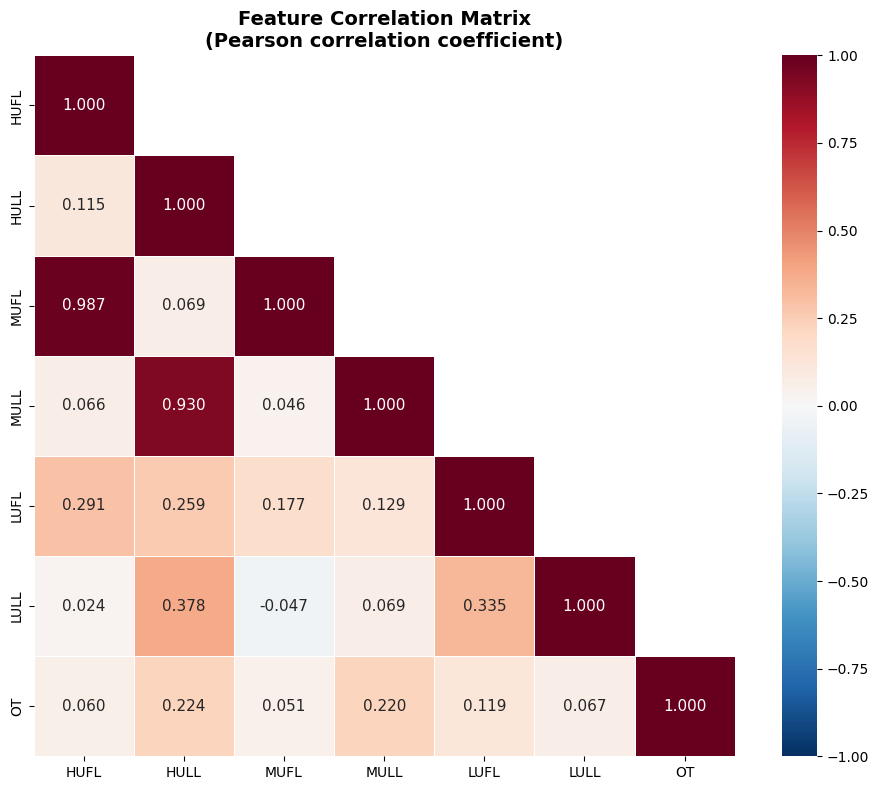


=== Correlation with OT (target) ===
  HUFL   → r = +0.060
  HULL   → r = +0.224
  MUFL   → r = +0.051
  MULL   → r = +0.220
  LUFL   → r = +0.119
  LULL   → r = +0.067

Top 3 predictors: ['HULL', 'MULL', 'LUFL']


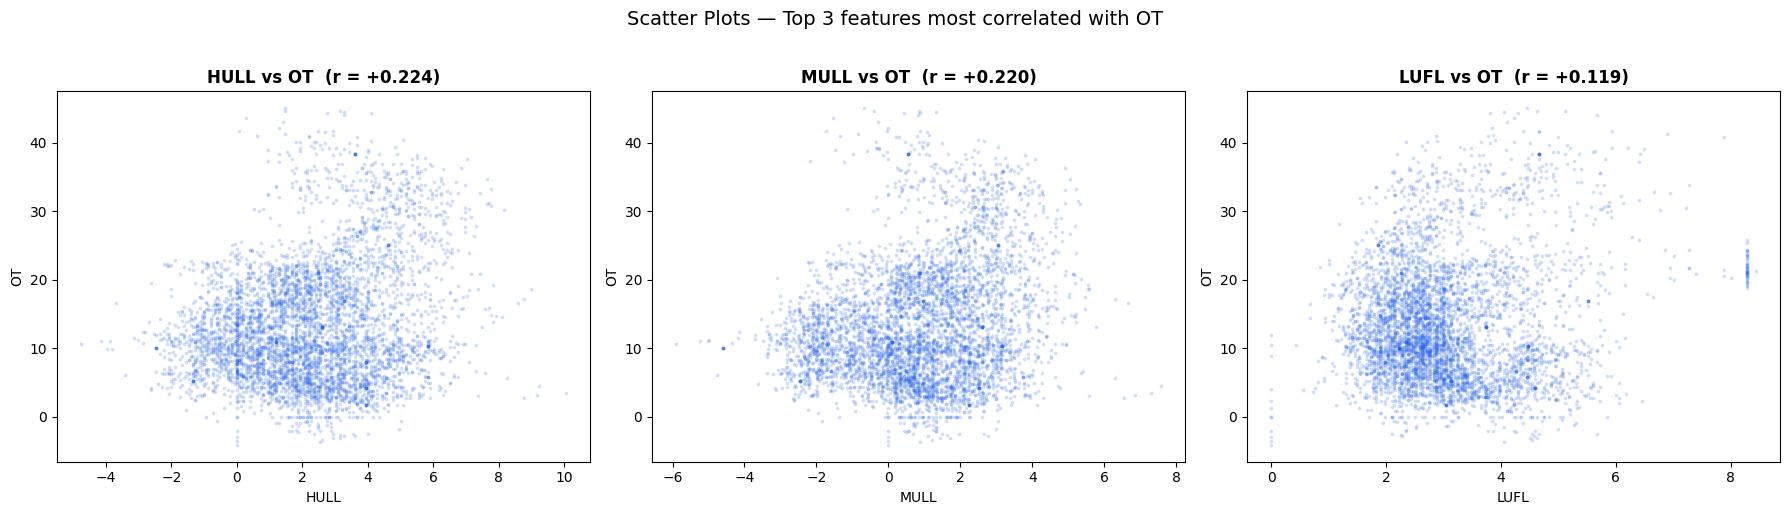


=== Highly correlated feature pairs (|r| > 0.90) ===
These pairs are nearly redundant — consider dropping one.

    HUFL ↔ MUFL    r = +0.987
    HULL ↔ MULL    r = +0.930


In [16]:
#5) Correlation in heatmap for evaluation of 7 feature to recognize which would impact mostly to the OT
# ============================================================
# STEP 4: CORRELATION ANALYSIS
# Purpose: Understand relationships BETWEEN features.
#   - Which load features are most related to OT?
#   - Are some features redundant (near-perfect correlation)?
#   - This directly impacts feature selection for modeling.
# Why this matters:
#   - Highly correlated features with OT → strong predictors
#   - Highly correlated features with EACH OTHER → redundancy
#     (may cause multicollinearity, or you can drop one)
# ============================================================

# --- Part 1: Correlation heatmap ---
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # hide upper triangle (it's symmetric)

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, ax=ax,
            vmin=-1, vmax=1,
            annot_kws={'size': 11},
            linewidths=0.5, linecolor='white')
ax.set_title('Feature Correlation Matrix\n(Pearson correlation coefficient)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Part 2: Scatter plots of top correlated features with OT ---
# Pick the 3 features most correlated with OT
ot_corr = corr['OT'].drop('OT').abs().sort_values(ascending=False)
top3 = ot_corr.head(3).index.tolist()

print(f"\n=== Correlation with OT (target) ===")
for feat in features[:-1]:  # exclude OT itself
    print(f"  {feat:<6} → r = {corr.loc[feat, 'OT']:+.3f}")
print(f"\nTop 3 predictors: {top3}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3):
    # Subsample for faster plotting (69k points is too dense)
    sample = df.sample(n=5000, random_state=42)
    axes[i].scatter(sample[feat], sample['OT'], alpha=0.15, s=3, color='#2563eb')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('OT')
    r = corr.loc[feat, 'OT']
    axes[i].set_title(f'{feat} vs OT  (r = {r:+.3f})', fontsize=12, fontweight='bold')

fig.suptitle('Scatter Plots — Top 3 features most correlated with OT', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Part 3: Check for redundant features ---
# If two features have correlation > 0.95, they carry almost the same info
# You might consider dropping one to reduce model complexity
print("\n=== Highly correlated feature pairs (|r| > 0.90) ===")
print("These pairs are nearly redundant — consider dropping one.\n")
for i in range(len(features)):
    for j in range(i+1, len(features)):
        r = corr.iloc[i, j]
        if abs(r) > 0.90:
            print(f"  {features[i]:>6} ↔ {features[j]:<6}  r = {r:+.3f}")

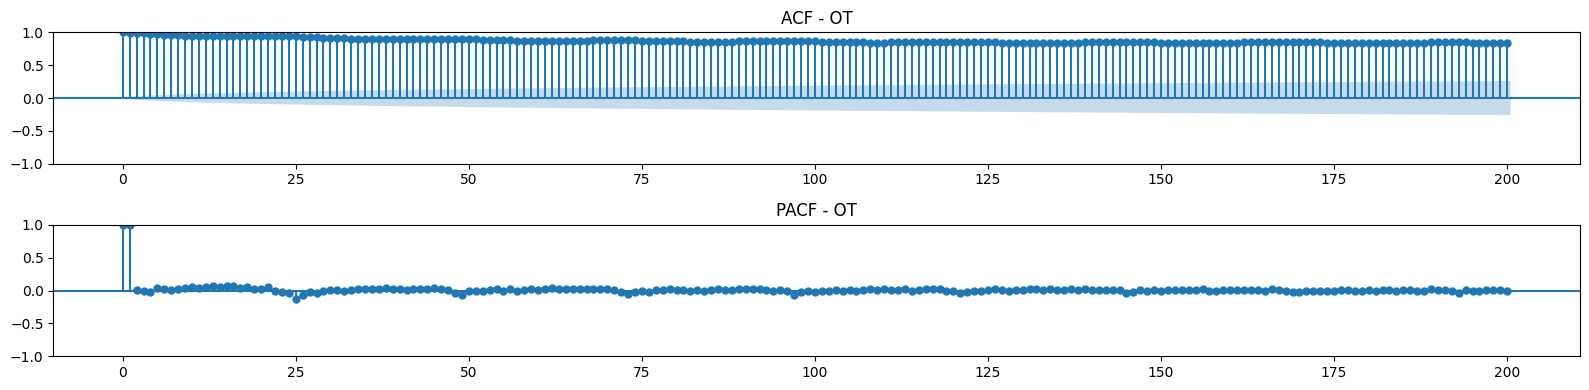

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 4))
plot_acf(df["OT"].dropna(), lags=200, ax=axes[0],title="ACF - OT")
plot_pacf(df["OT"].dropna(), lags=200, ax=axes[1],title="PACF - OT")
plt.tight_layout()

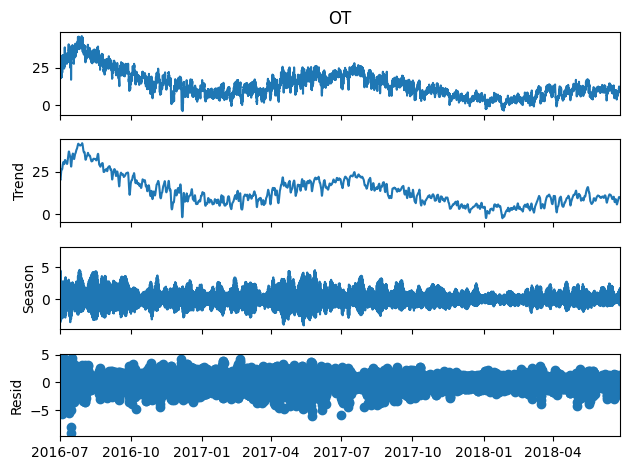

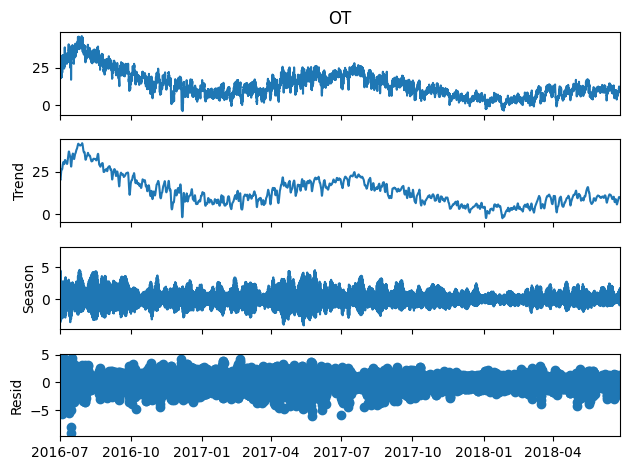

In [8]:
from statsmodels.tsa.seasonal import STL

stl = STL(df["OT"], period=24)  # daily seasonality
result = stl.fit()
result.plot()